In [1]:
import pandas as pd
from pipeline import create_X_y_df
import numpy as np
from datetime import timedelta

In [2]:
full_dataset_df = pd.read_parquet("../../data/churn-prediction-25-26/train.parquet")

In [3]:
df = full_dataset_df.copy()

In [4]:
# Second Train Test set
cut_off_date_train = pd.Timestamp("2018-11-05")
cut_off_date_test = pd.Timestamp("2018-11-15")

df_X, df_y = create_X_y_df(df = df,
                                t0=cut_off_date_train,
                                t1=cut_off_date_test)

In [5]:
df_X["date"] = pd.to_datetime(df_X["time"]).dt.date

df_X = df_X.sort_values(["userId", "time"])

df_X_1 = df_X.groupby(["userId", "date"])["length"].sum().reset_index()

In [6]:
start_date = df_X_1["date"].min()
end_date = df_X_1["date"].max()

In [7]:
df_user_id_date = pd.DataFrame()

In [8]:
df_user_id_date["userId"] = df_X_1["userId"].unique()

In [9]:
df_merge_days = pd.DataFrame()

df_merge_days["date"] = np.arange(start_date, end_date + timedelta(days = 1), timedelta(days = 1))

In [10]:
df_merge_days["date"] = pd.to_datetime(df_merge_days["date"]).dt.date

In [11]:
df_user_id_days = df_user_id_date.merge(df_merge_days, how="cross")

In [12]:
df_user_id_days

,userId,date
0,1000035,2018-10-01
1,1000035,2018-10-02
2,1000035,2018-10-03
3,1000035,2018-10-04
4,1000035,2018-10-05
...,...,...
555583,1999905,2018-11-01
555584,1999905,2018-11-02
555585,1999905,2018-11-03
555586,1999905,2018-11-04


In [13]:
df_X_1_merge = df_X_1.merge(df_user_id_days, on = ["userId", "date"], how="right")

In [14]:
df_X_1_merge["date"] = pd.to_datetime(df_X_1_merge["date"])

In [15]:
df_X_1_merge["length"] = df_X_1_merge["length"].fillna(0.0)

In [16]:
df_X_1_merge

,userId,date,length
0,1000035,2018-10-01,0.00000
1,1000035,2018-10-02,0.00000
2,1000035,2018-10-03,0.00000
3,1000035,2018-10-04,0.00000
4,1000035,2018-10-05,625.63129
...,...,...,...
555583,1999905,2018-11-01,0.00000
555584,1999905,2018-11-02,0.00000
555585,1999905,2018-11-03,0.00000
555586,1999905,2018-11-04,0.00000


In [17]:
df_X_1_merge = df_X_1_merge.sort_values(["userId", "date"], ascending=True)

In [18]:
df_X_1_merge["rolling_avg"] = df_X_1_merge.groupby(["userId"])["length"].\
    transform(lambda s: s.rolling(window = 4).mean())

In [19]:
df_X_1_merge

,userId,date,length,rolling_avg
0,1000035,2018-10-01,0.00000,NaN
1,1000035,2018-10-02,0.00000,NaN
2,1000035,2018-10-03,0.00000,NaN
3,1000035,2018-10-04,0.00000,0.000000
4,1000035,2018-10-05,625.63129,156.407823
...,...,...,...,...
555583,1999905,2018-11-01,0.00000,2524.338198
555584,1999905,2018-11-02,0.00000,2524.338198
555585,1999905,2018-11-03,0.00000,2524.338198
555586,1999905,2018-11-04,0.00000,0.000000


In [20]:
#df_X_1_merge[pd.isna(df_X_1_merge["rolling_avg"])]["rolling_avg"] = df_X_1_merge.groupby(["userId"])

df_temp = df_X_1_merge[~pd.isna(df_X_1_merge["rolling_avg"])].groupby(["userId"])["date"].min()

df_first_rolling_avg = df_X_1_merge.merge(df_temp, on=["userId", "date"])

In [21]:
df_first_rolling_avg_dropped = df_first_rolling_avg[["userId", "rolling_avg"]]

In [22]:
df_first_rolling_avg

,userId,date,length,rolling_avg
0,1000035,2018-10-04,0.00000,0.000000
1,1000103,2018-10-04,9769.04682,2442.261705
2,1000164,2018-10-04,0.00000,56.855398
3,1000168,2018-10-04,9864.81080,2466.202700
4,1000182,2018-10-04,0.00000,0.000000
...,...,...,...,...
15428,1999241,2018-10-04,0.00000,1928.982380
15429,1999382,2018-10-04,0.00000,2106.308208
15430,1999781,2018-10-04,0.00000,20226.307082
15431,1999848,2018-10-04,14956.06974,6358.343285


In [23]:
df_first_rolling_avg_dropped

,userId,rolling_avg
0,1000035,0.000000
1,1000103,2442.261705
2,1000164,56.855398
3,1000168,2466.202700
4,1000182,0.000000
...,...,...
15428,1999241,1928.982380
15429,1999382,2106.308208
15430,1999781,20226.307082
15431,1999848,6358.343285


In [24]:
df_X_1_merge = df_X_1_merge.merge(df_first_rolling_avg_dropped, on = "userId")

In [25]:

mask = df_X_1_merge["rolling_avg_x"].isna()
df_X_1_merge.loc[mask, "rolling_avg_x"] = df_X_1_merge.loc[mask, "rolling_avg_y"]


#df_X_1_merge[pd.isna(df_X_1_merge["rolling_avg_x"])]["rolling_avg_x"] = df_X_1_merge[pd.isna(df_X_1_merge["rolling_avg_x"])]["rolling_avg_y"]

In [26]:
df_X_1_merge = df_X_1_merge[["userId", "date", "length", "rolling_avg_x"]]

In [27]:
df_X_1_merge = df_X_1_merge.rename(columns={"rolling_avg_x" : "rolling_avg"})

In [28]:
df_X_1_merge

,userId,date,length,rolling_avg
0,1000035,2018-10-01,0.00000,0.000000
1,1000035,2018-10-02,0.00000,0.000000
2,1000035,2018-10-03,0.00000,0.000000
3,1000035,2018-10-04,0.00000,0.000000
4,1000035,2018-10-05,625.63129,156.407823
...,...,...,...,...
555583,1999905,2018-11-01,0.00000,2524.338198
555584,1999905,2018-11-02,0.00000,2524.338198
555585,1999905,2018-11-03,0.00000,2524.338198
555586,1999905,2018-11-04,0.00000,0.000000


In [29]:
#df_X_1_merge["abs_usage_change_7_days"] = df_X_1_merge.groupby("userId")["rolling_avg"].diff(7)

In [30]:
#df_X_1_merge["week_number"] = df_X_1_merge["date"].dt.isocalendar().week

df_X_1_merge["date"] = pd.to_datetime(df_X_1_merge["date"])

In [31]:
df_X_1_merge["week_number"] = df_X_1_merge["date"].dt.isocalendar().week

In [32]:
df_X_1_merge

,userId,date,length,rolling_avg,week_number
0,1000035,2018-10-01,0.00000,0.000000,40
1,1000035,2018-10-02,0.00000,0.000000,40
2,1000035,2018-10-03,0.00000,0.000000,40
3,1000035,2018-10-04,0.00000,0.000000,40
4,1000035,2018-10-05,625.63129,156.407823,40
...,...,...,...,...,...
555583,1999905,2018-11-01,0.00000,2524.338198,44
555584,1999905,2018-11-02,0.00000,2524.338198,44
555585,1999905,2018-11-03,0.00000,2524.338198,44
555586,1999905,2018-11-04,0.00000,0.000000,44


In [33]:
df_X_1_merge["weekly_average"] = df_X_1_merge.groupby(["userId", "week_number"])["rolling_avg"].transform("mean")

In [34]:
df_X_1_merge

,userId,date,length,rolling_avg,week_number,weekly_average
0,1000035,2018-10-01,0.00000,0.000000,40,67.031924
1,1000035,2018-10-02,0.00000,0.000000,40,67.031924
2,1000035,2018-10-03,0.00000,0.000000,40,67.031924
3,1000035,2018-10-04,0.00000,0.000000,40,67.031924
4,1000035,2018-10-05,625.63129,156.407823,40,67.031924
...,...,...,...,...,...,...
555583,1999905,2018-11-01,0.00000,2524.338198,44,1718.994804
555584,1999905,2018-11-02,0.00000,2524.338198,44,1718.994804
555585,1999905,2018-11-03,0.00000,2524.338198,44,1718.994804
555586,1999905,2018-11-04,0.00000,0.000000,44,1718.994804


In [35]:
df_weekly_avg_time = df_X_1_merge[["userId", "week_number", "weekly_average"]].drop_duplicates()

In [36]:
df_weekly_avg_time = df_weekly_avg_time.sort_values(["userId", "week_number"], ascending=False)

In [37]:
# Compute differences
df_weekly_avg_time = df_weekly_avg_time[df_weekly_avg_time["week_number"] != 45]


#df_weekly_avg_time["delta_week_before"] = df_weekly_avg_time.groupby(["userId"])["weekly_average"].diff(1)

In [38]:
df_weekly_avg_time = df_weekly_avg_time.pivot(index = "userId", columns="week_number", values = "weekly_average")
cols = df_weekly_avg_time.columns

In [39]:
#df_weekly_avg_time[40]

for i, week_number in enumerate(cols):
    if i == len(cols) - 1:
        continue
    else:
        df_weekly_avg_time[f"delta_week_{cols[-1]}_{week_number}"] = df_weekly_avg_time[cols[-1]] - df_weekly_avg_time[week_number]

df_c = df_weekly_avg_time.copy()


#df_weekly_avg_time[40]

for i, week_number in enumerate(cols):
    if i == len(cols) - 1:
        continue
    else:
        df_weekly_avg_time[f"%_delta_week_{cols[-1]}_{week_number}"] = ((df_weekly_avg_time[cols[-1]] - df_weekly_avg_time[week_number]) / df_weekly_avg_time[week_number]) * 100


df_weekly_avg_time = df_weekly_avg_time.fillna(0.0)
df_weekly_avg_time = df_weekly_avg_time.replace(np.inf, None)

df_d = df_weekly_avg_time.copy()

In [40]:
df_weekly_avg_time

week_number,40,41,42,43,44,delta_week_44_40,delta_week_44_41,delta_week_44_42,delta_week_44_43,%_delta_week_44_40,%_delta_week_44_41,%_delta_week_44_42,%_delta_week_44_43
userId,,,,,,,,,,,,,
1000035,67.031924,2324.556103,9592.823503,7576.029159,6107.531961,6040.500037,3782.975858,-3485.291541,-1468.497198,9011.377988,162.73971,-36.33228,-19.383468
1000103,2442.261705,0.000000,0.000000,300.171497,100.057166,-2342.204539,100.057166,100.057166,-200.114331,-95.903094,None,None,-66.666667
1000164,51.911756,4129.249891,7189.057606,1122.994641,628.672950,576.761194,-3500.576941,-6560.384656,-494.321691,1111.041578,-84.775129,-91.255141,-44.01817
1000168,3500.750395,4498.733761,5246.588110,118.202005,0.000000,-3500.750395,-4498.733761,-5246.588110,-118.202005,-100.0,-100.0,-100.0,-100.0
1000182,0.000000,0.000000,1344.070110,2560.594153,2490.047782,2490.047782,2490.047782,1145.977672,-70.546371,None,None,85.261748,-2.755078
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999241,1377.844557,0.000000,1351.319484,4617.234743,1519.984027,142.139470,1519.984027,168.664543,-3097.250716,10.316074,None,12.481471,-67.080209
1999382,1805.407035,0.000000,0.000000,0.000000,0.000000,-1805.407035,0.000000,0.000000,0.000000,-100.0,0.0,0.0,0.0
1999781,14359.895913,3599.188684,4180.787605,8271.014831,39866.309191,25506.413278,36267.120507,35685.521586,31595.294360,177.62255,1007.647103,853.559783,382.000214


In [41]:
cols_delta = ["delta_week_44_40","delta_week_44_41","delta_week_44_42","delta_week_44_43"]
df_weekly_avg_time["mean_weekly_delta"] = df_weekly_avg_time[cols_delta].mean(axis=1)

cols_delta = ["delta_week_44_40","delta_week_44_41","delta_week_44_42","delta_week_44_43"]
df_weekly_avg_time["median_weekly_delta"] = df_weekly_avg_time[cols_delta].median(axis=1)

cols_delta = ["delta_week_44_40","delta_week_44_41","delta_week_44_42","delta_week_44_43"]
df_weekly_avg_time["var_weekly_delta"] = df_weekly_avg_time[cols_delta].var(axis=1)

In [42]:
cols_delta_p = ["%_delta_week_44_40","%_delta_week_44_41","%_delta_week_44_42","%_delta_week_44_43"]
df_weekly_avg_time["mean_weekly_delta_%"] = df_weekly_avg_time[cols_delta_p].mean(axis=1)

cols_delta_p = ["%_delta_week_44_40","%_delta_week_44_41","%_delta_week_44_42","%_delta_week_44_43"]
df_weekly_avg_time["median_weekly_delta_%"] = df_weekly_avg_time[cols_delta_p].median(axis=1)

cols_delta_p = ["%_delta_week_44_40","%_delta_week_44_41","%_delta_week_44_42","%_delta_week_44_43"]
df_weekly_avg_time["var_weekly_delta_%"] = df_weekly_avg_time[cols_delta_p].var(axis=1)

In [43]:
df_weekly_avg_time

week_number,40,41,42,43,44,delta_week_44_40,delta_week_44_41,delta_week_44_42,delta_week_44_43,%_delta_week_44_40,%_delta_week_44_41,%_delta_week_44_42,%_delta_week_44_43,mean_weekly_delta,median_weekly_delta,var_weekly_delta,mean_weekly_delta_%,median_weekly_delta_%,var_weekly_delta_%
userId,,,,,,,,,,,,,,,,,,,
1000035,67.031924,2324.556103,9592.823503,7576.029159,6107.531961,6040.500037,3782.975858,-3485.291541,-1468.497198,9011.377988,162.73971,-36.33228,-19.383468,1217.421789,1157.239330,1.972461e+07,2279.600487,71.678121,20148933.225162
1000103,2442.261705,0.000000,0.000000,300.171497,100.057166,-2342.204539,100.057166,100.057166,-200.114331,-95.903094,None,None,-66.666667,-585.551135,-50.028583,1.391503e+06,-81.28488,-81.28488,427.384342
1000164,51.911756,4129.249891,7189.057606,1122.994641,628.672950,576.761194,-3500.576941,-6560.384656,-494.321691,1111.041578,-84.775129,-91.255141,-44.01817,-2494.630524,-1997.449316,1.032566e+07,222.748284,-64.39665,351132.706099
1000168,3500.750395,4498.733761,5246.588110,118.202005,0.000000,-3500.750395,-4498.733761,-5246.588110,-118.202005,-100.0,-100.0,-100.0,-100.0,-3341.068568,-3999.742078,5.127854e+06,-100.0,-100.0,0.0
1000182,0.000000,0.000000,1344.070110,2560.594153,2490.047782,2490.047782,2490.047782,1145.977672,-70.546371,None,None,85.261748,-2.755078,1513.881716,1818.012727,1.517189e+06,41.253335,41.253335,3873.480863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999241,1377.844557,0.000000,1351.319484,4617.234743,1519.984027,142.139470,1519.984027,168.664543,-3097.250716,10.316074,None,12.481471,-67.080209,-316.615669,155.402006,3.850328e+06,-14.760888,10.316074,2054.155746
1999382,1805.407035,0.000000,0.000000,0.000000,0.000000,-1805.407035,0.000000,0.000000,0.000000,-100.0,0.0,0.0,0.0,-451.351759,0.000000,8.148736e+05,-25.0,0.0,2500.0
1999781,14359.895913,3599.188684,4180.787605,8271.014831,39866.309191,25506.413278,36267.120507,35685.521586,31595.294360,177.62255,1007.647103,853.559783,382.000214,32263.587433,33640.407973,2.461464e+07,605.207412,617.779998,152095.624141


In [44]:
import seaborn as sns

In [45]:
df_a = df_weekly_avg_time.merge(df_y, on = "userId")

In [46]:
df_a.columns

Index([                   'userId',                          40,
                                41,                          42,
                                43,                          44,
                'delta_week_44_40',          'delta_week_44_41',
                'delta_week_44_42',          'delta_week_44_43',
              '%_delta_week_44_40',        '%_delta_week_44_41',
              '%_delta_week_44_42',        '%_delta_week_44_43',
               'mean_weekly_delta',       'median_weekly_delta',
                'var_weekly_delta',       'mean_weekly_delta_%',
           'median_weekly_delta_%',        'var_weekly_delta_%',
       'Cancellation Confirmation'],
      dtype='object')

<Axes: xlabel='Cancellation Confirmation', ylabel='var_weekly_delta_%'>

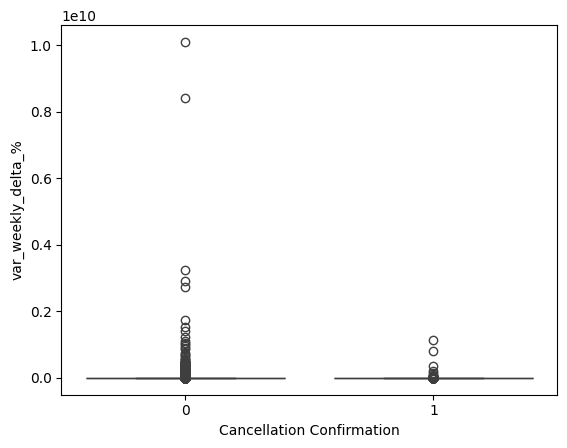

In [47]:
sns.boxplot(df_a, x = "Cancellation Confirmation", y = "var_weekly_delta_%")

In [48]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

In [49]:
#clf = HistGradientBoostingClassifier(max_depth=100, class_weight={np.int8(0): np.float64(0.5250034018233773),
# np.int8(1): np.float64(10.498639455782312)})

clf = HistGradientBoostingClassifier()

In [50]:
df_a = df_a.rename(columns={
    40: "40",
    41: "41",
    42: "42",
    43: "43",
    44: "44"
})

In [51]:
df_a.columns

Index(['userId', '40', '41', '42', '43', '44', 'delta_week_44_40',
       'delta_week_44_41', 'delta_week_44_42', 'delta_week_44_43',
       '%_delta_week_44_40', '%_delta_week_44_41', '%_delta_week_44_42',
       '%_delta_week_44_43', 'mean_weekly_delta', 'median_weekly_delta',
       'var_weekly_delta', 'mean_weekly_delta_%', 'median_weekly_delta_%',
       'var_weekly_delta_%', 'Cancellation Confirmation'],
      dtype='object')

In [52]:
X = df_a[['40', '41', '42', '43', '44', 'delta_week_44_40',
       'delta_week_44_41', 'delta_week_44_42', 'delta_week_44_43',
       '%_delta_week_44_40', '%_delta_week_44_41', '%_delta_week_44_42',
       '%_delta_week_44_43', 'mean_weekly_delta', 'mean_weekly_delta_%',
       'median_weekly_delta_%', 'median_weekly_delta', 'var_weekly_delta',
       'var_weekly_delta_%']]

y = df_a["Cancellation Confirmation"]

X_train, X_test, y_train, y_test = train_test_split(X, y)

In [53]:
classes = np.unique(y)
w = compute_class_weight("balanced", classes=classes, y=y)

In [54]:
class_weight = dict(zip(classes, w))

In [55]:
class_weight

{np.int8(0): np.float64(0.5250034018233773),
 np.int8(1): np.float64(10.498639455782312)}

In [56]:
clf.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,max_iter,100
,max_leaf_nodes,31
,max_depth,None
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


In [57]:
clf.score(X_test, y_test)

0.94998704327546

In [58]:
pred = clf.predict(X_test)

confusion_matrix(y_test, pred)

array([[3666,    1],
       [ 192,    0]])

In [59]:
df_y[df_y["Cancellation Confirmation"] == 1]

,userId,Cancellation Confirmation
17,1240184,1
30,1418529,1
41,1642905,1
54,1162900,1
57,1202559,1
...,...,...
14701,1381416,1
14800,1333772,1
14858,1689553,1
14860,1181686,1


In [60]:
from xgboost import XGBClassifier

In [61]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11574 entries, 11326 to 5705
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   40                     11574 non-null  float64
 1   41                     11574 non-null  float64
 2   42                     11574 non-null  float64
 3   43                     11574 non-null  float64
 4   44                     11574 non-null  float64
 5   delta_week_44_40       11574 non-null  float64
 6   delta_week_44_41       11574 non-null  float64
 7   delta_week_44_42       11574 non-null  float64
 8   delta_week_44_43       11574 non-null  float64
 9   %_delta_week_44_40     9185 non-null   object 
 10  %_delta_week_44_41     9749 non-null   object 
 11  %_delta_week_44_42     9751 non-null   object 
 12  %_delta_week_44_43     10156 non-null  object 
 13  mean_weekly_delta      11574 non-null  float64
 14  mean_weekly_delta_%    11247 non-null  object 
 15  medi

In [62]:
X_train["%_delta_week_44_40"] = pd.to_numeric(X_train["%_delta_week_44_40"])
X_train["%_delta_week_44_41"] = pd.to_numeric(X_train["%_delta_week_44_41"])
X_train["%_delta_week_44_42"] = pd.to_numeric(X_train["%_delta_week_44_42"])
X_train["%_delta_week_44_43"] = pd.to_numeric(X_train["%_delta_week_44_43"])

X_train["mean_weekly_delta_%"] = pd.to_numeric(X_train["mean_weekly_delta_%"])
X_train["median_weekly_delta_%"] = pd.to_numeric(X_train["median_weekly_delta_%"])
X_train["var_weekly_delta_%"] = pd.to_numeric(X_train["var_weekly_delta_%"])



X_test["%_delta_week_44_40"] = pd.to_numeric(X_test["%_delta_week_44_40"])
X_test["%_delta_week_44_41"] = pd.to_numeric(X_test["%_delta_week_44_41"])
X_test["%_delta_week_44_42"] = pd.to_numeric(X_test["%_delta_week_44_42"])
X_test["%_delta_week_44_43"] = pd.to_numeric(X_test["%_delta_week_44_43"])

X_test["mean_weekly_delta_%"] = pd.to_numeric(X_test["mean_weekly_delta_%"])
X_test["median_weekly_delta_%"] = pd.to_numeric(X_test["median_weekly_delta_%"])
X_test["var_weekly_delta_%"] = pd.to_numeric(X_test["var_weekly_delta_%"])

In [63]:
# 3) Model
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"  # avoids warning in many setups
)

xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)

confusion_matrix(y_test, pred)


array([[3663,    4],
       [ 192,    0]])